In [1]:
# !pip install torchmetrics optuna

In [2]:
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from sklearn.datasets import load_sample_images

sample_images = load_sample_images()['images']
sample_images = np.stack(sample_images)
sample_images = torch.FloatTensor(sample_images)
sample_images /= 255

In [4]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


In [5]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1,2,0))
    plt.axis('off')

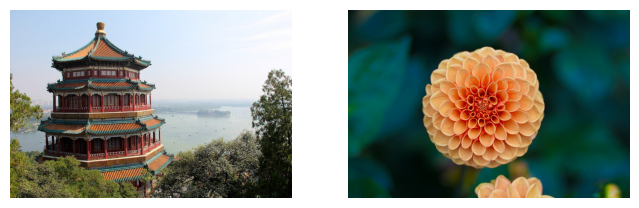

In [6]:
plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [7]:
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

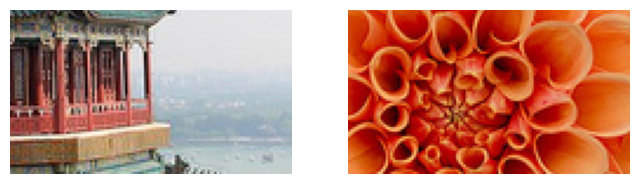

In [8]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plot_image(cropped_images[0])

plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [9]:
torch.manual_seed(42)

conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
print(cropped_images.shape)
print(conv_layer.weight.shape, conv_layer.padding,  conv_layer.stride)

fmaps = conv_layer(cropped_images)
print(fmaps.shape)

torch.Size([2, 3, 70, 120])
torch.Size([32, 3, 7, 7]) (0, 0) (1, 1)
torch.Size([2, 32, 64, 114])


## features

In [12]:
# import torch.nn.functional as F

# F.conv2d(
#     cropped_images,
#     conv_layer.weight.data,
#     conv_layer.bias.data,
#     stride=1,
#     padding=0
# ).shape

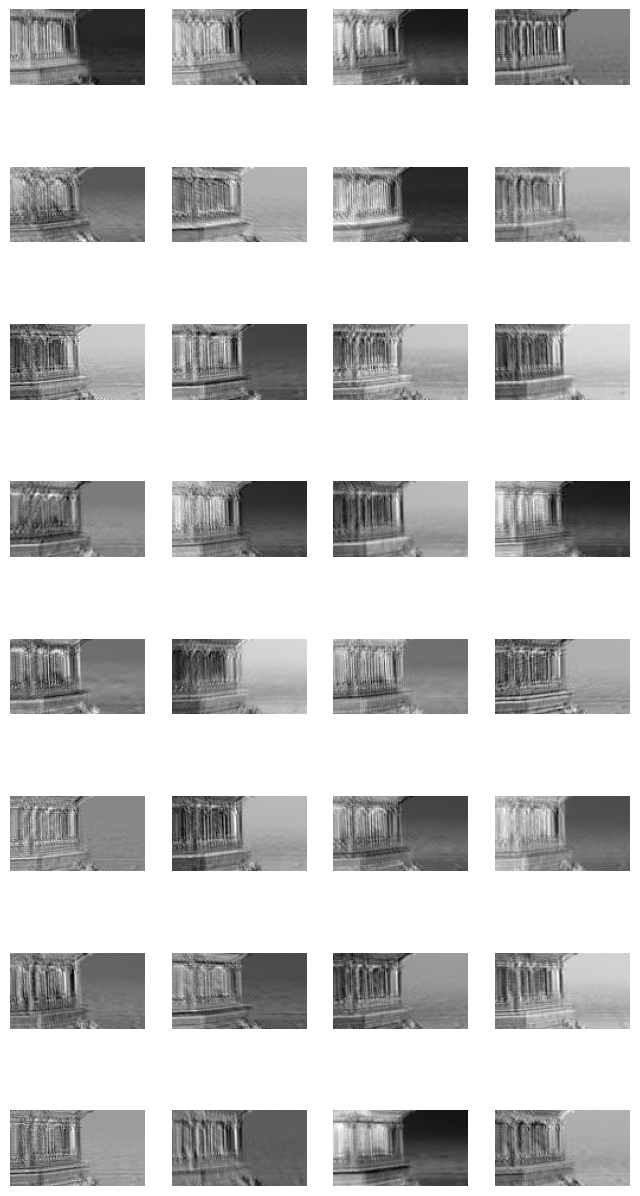

In [13]:
fig,axs = plt.subplots(8,4,figsize=(8,16))

for ind, ax in enumerate(axs.flat):
    ax.imshow(fmaps[0][ind].detach(), cmap='gray')
    ax.axis('off')

# pooling

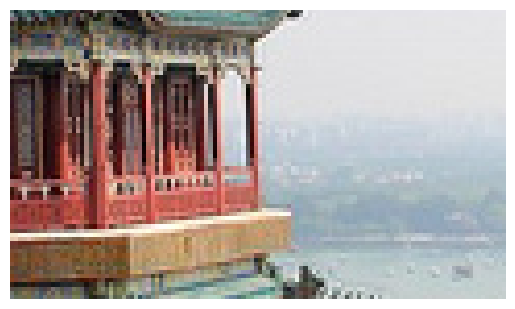

In [14]:
plot_image(cropped_images[0])

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


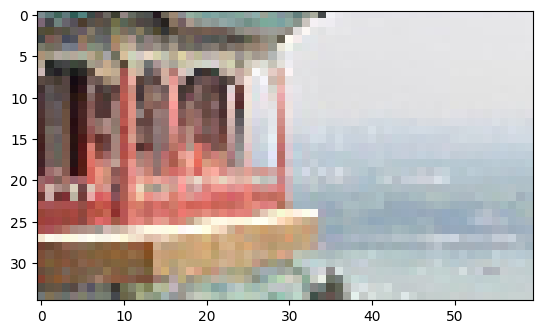

In [15]:
max_pool = nn.MaxPool2d(kernel_size=2)
output_max = max_pool(cropped_images)
print(cropped_images.shape)
print(output_max.shape)
plt.imshow(output_max[0].permute(1, 2, 0))

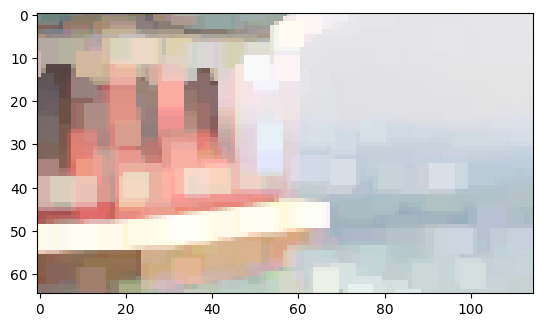

In [16]:
pooling_layer = nn.MaxPool2d(kernel_size=2, stride=1)

output = pooling_layer(cropped_images)
for i in range(4):
    output = pooling_layer(output)

plt.imshow(output[0].permute(1, 2, 0))

torch.Size([2, 3, 70, 120])
torch.Size([2, 3, 35, 60])


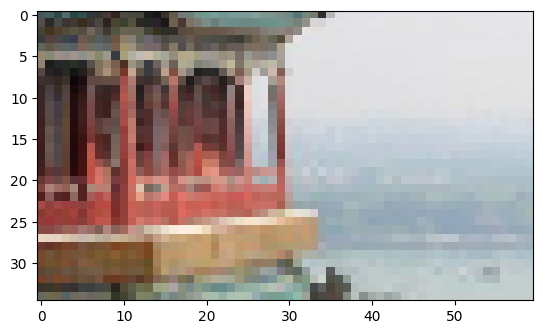

In [17]:
avg_pool = nn.AvgPool2d(kernel_size=2)
output_avg = avg_pool(cropped_images)
print(cropped_images.shape)
print(output_avg.shape)
plt.imshow(output_avg[0].permute(1, 2, 0))

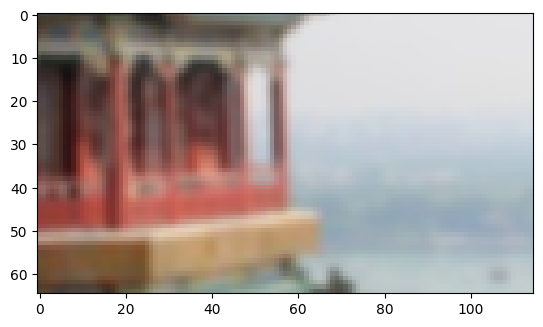

In [18]:
pooling_layer = nn.AvgPool2d(kernel_size=2, stride=1)

output = pooling_layer(cropped_images)
for i in range(4):
    output = pooling_layer(output)

plt.imshow(output[0].permute(1, 2, 0))

In [19]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))
output = global_avg_pool(cropped_images)
output.shape

torch.Size([2, 3, 1, 1])

In [20]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = global_avg_pool(cropped_images)
# output = cropped_images.mean(dim=(2, 3), keepdim=True)
output.shape

torch.Size([2, 3, 1, 1])

# train a classifier

In [21]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="data", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])
# train_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])
# valid_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])

from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

# from functools import partial

# torch.manual_seed(42)  # extra code – ensure reproducibility
# DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")
# model = nn.Sequential(
#     DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
#     DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
#     DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2),
#     nn.Flatten(),
#     nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(in_features=128, out_features=64), nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(in_features=64, out_features=10),
# ).to(device)

model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding="same"), # [32, 64, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 64, 14, 14]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 128, 7, 7]
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 256, 3, 3]
    nn.Flatten(), # [32, 2304]
    nn.Linear(in_features=2304, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [ ]:
from custom_utils import train, plot_history

n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(
	model,
	optimizer,
	criterion,
	metric,
	train_loader,
	valid_loader,
	n_epochs,
	warmup_scheduler=None,
	scheduler=None,
	patience=None,
	checkpoint_path='fashion_mnist_model.pt',
	clip_grad_norm=None,
  device=device
)

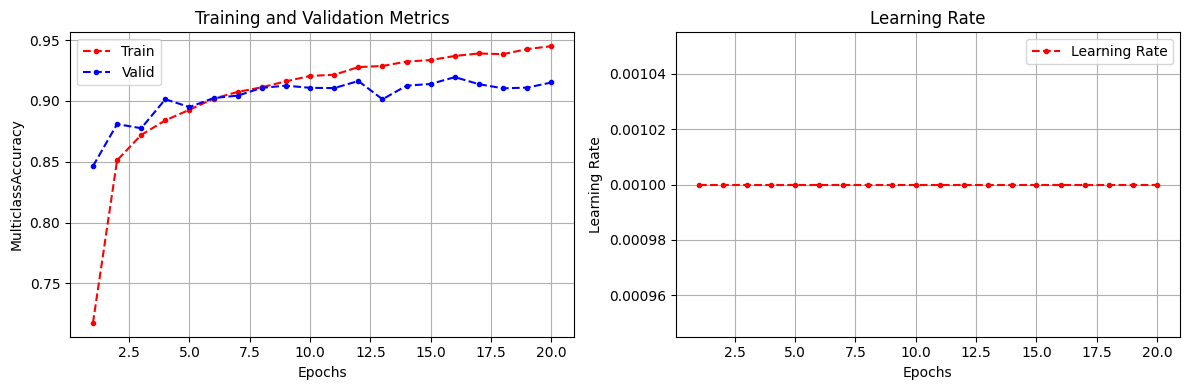

In [33]:
plot_history(history, metric)

In [39]:
param_iter = iter(model.parameters())

In [46]:
model[0].weight.numel()

3136

In [47]:
model[0].bias.numel()

64

In [52]:
model[3]

Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)

In [54]:
128 * 9 * 64

73728

In [55]:
model[3].bias.numel()

128

In [40]:
w = next(param_iter)
w

Parameter containing:
tensor([[[[ 0.1092,  0.1186, -0.0335,  ..., -0.0313,  0.0288, -0.0696],
          [ 0.0839,  0.1259, -0.1048,  ...,  0.0267,  0.1055,  0.0193],
          [ 0.0689, -0.0202,  0.1101,  ..., -0.0667,  0.0364, -0.0658],
          ...,
          [ 0.0135, -0.1411,  0.1290,  ...,  0.1103,  0.0238, -0.0464],
          [ 0.0883,  0.0223,  0.1154,  ..., -0.0451,  0.0384, -0.0387],
          [ 0.0601,  0.1275,  0.0826,  ...,  0.0825,  0.0256,  0.0725]]],


        [[[-0.0871, -0.1414, -0.0552,  ...,  0.1172,  0.0411,  0.0592],
          [ 0.0452, -0.0025,  0.1118,  ...,  0.0090, -0.0975,  0.0441],
          [-0.0492,  0.0438, -0.0298,  ..., -0.0847, -0.0852, -0.0852],
          ...,
          [ 0.0579,  0.0512,  0.1187,  ..., -0.0974,  0.0758, -0.0577],
          [ 0.0867, -0.0339,  0.0817,  ..., -0.0721,  0.0436,  0.0302],
          [-0.0364,  0.0852,  0.0971,  ..., -0.0763,  0.1308, -0.0482]]],


        [[[-0.0506, -0.1382, -0.0818,  ..., -0.0189, -0.1037,  0.0034],
    

In [42]:
w.numel()

3136

In [31]:
sum([param.numel() for param in model.parameters()])

1413834

# Using TorchVision's Pretrained Models

In [60]:
import requests

url = r'https://docs.pytorch.org/vision/main/models.html'
res = requests.get(url)
res.content

b'\n\n\n<!DOCTYPE html>\n<!--[if IE 8]><html class="no-js lt-ie9" lang="en" > <![endif]-->\n<!--[if gt IE 8]><!--> <html class="no-js" lang="en" > <!--<![endif]-->\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="Docutils 0.18.1: http://docutils.sourceforge.net/" />\n\n  <meta name="viewport" content="width=device-width, initial-scale=1.0">\n  \n  <title>Models and pre-trained weights &mdash; Torchvision main documentation</title>\n  \n\n  \n  \n  \n  \n\n  \n\n  \n  \n    \n\n  \n\n  <link rel="stylesheet" href="_static/css/theme.css" type="text/css" />\n  <!-- <link rel="stylesheet" href="_static/pygments.css" type="text/css" /> -->\n  <link rel="stylesheet" href="_static/pygments.css" type="text/css" />\n  <link rel="stylesheet" href="_static/css/theme.css" type="text/css" />\n  <link rel="stylesheet" href="_static/copybutton.css" type="text/css" />\n  <link rel="stylesheet" href="_static/sg_gallery.css" type="text/css" />\n  <link rel="stylesheet" href="_static/

In [63]:
import bs4

soup = bs4.BeautifulSoup(res.content, 'html.parser')
soup


<!DOCTYPE html>

<!--[if IE 8]><html class="no-js lt-ie9" lang="en" > <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en"> <!--<![endif]-->
<head>
<meta charset="utf-8"/>
<meta content="Docutils 0.18.1: http://docutils.sourceforge.net/" name="generator">
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<title>Models and pre-trained weights — Torchvision main documentation</title>
<link href="_static/css/theme.css" rel="stylesheet" type="text/css"/>
<!-- <link rel="stylesheet" href="_static/pygments.css" type="text/css" /> -->
<link href="_static/pygments.css" rel="stylesheet" type="text/css"/>
<link href="_static/css/theme.css" rel="stylesheet" type="text/css"/>
<link href="_static/copybutton.css" rel="stylesheet" type="text/css"/>
<link href="_static/sg_gallery.css" rel="stylesheet" type="text/css"/>
<link href="_static/sg_gallery-binder.css" rel="stylesheet" type="text/css"/>
<link href="_static/sg_gallery-dataframe.css" rel="stylesheet" type="te

In [66]:
section = soup.find('section', id='table-of-all-available-classification-weights')
table = section.find('table')

In [69]:
import pandas as pd

In [71]:
# pd.read_html(table.text)

In [77]:
rows = table.find_all('tr')

df_columns = [header.text for header in rows[0].find_all('th')]
df_columns

['Weight', 'Acc@1', 'Acc@5', 'Params', 'GFLOPS', 'Recipe']

In [91]:
df_rows = []

for row in rows[1:]:
	tr = [td.text for td in row.find_all('td')]
	df_rows.append(tr)

df = pd.DataFrame(data=df_rows, columns=df_columns)
df

,Weight,Acc@1,Acc@5,Params,GFLOPS,Recipe
0,AlexNet_Weights.IMAGENET1K_V1,56.522,79.066,61.1M,0.71,link
1,ConvNeXt_Base_Weights.IMAGENET1K_V1,84.062,96.87,88.6M,15.36,link
2,ConvNeXt_Large_Weights.IMAGENET1K_V1,84.414,96.976,197.8M,34.36,link
3,ConvNeXt_Small_Weights.IMAGENET1K_V1,83.616,96.65,50.2M,8.68,link
4,ConvNeXt_Tiny_Weights.IMAGENET1K_V1,82.52,96.146,28.6M,4.46,link
...,...,...,...,...,...,...
110,ViT_L_32_Weights.IMAGENET1K_V1,76.972,93.07,306.5M,15.38,link
111,Wide_ResNet101_2_Weights.IMAGENET1K_V1,78.848,94.284,126.9M,22.75,link
112,Wide_ResNet101_2_Weights.IMAGENET1K_V2,82.51,96.02,126.9M,22.75,link
113,Wide_ResNet50_2_Weights.IMAGENET1K_V1,78.468,94.086,68.9M,11.4,link


In [107]:
mask = df['Params'].str.split('M').str[0].astype('float') < 100
df.loc[mask, :].sort_values(by=['Acc@1', 'Acc@5'], ascending=[False, False])[:20]

,Weight,Acc@1,Acc@5,Params,GFLOPS,Recipe
51,RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1,86.012,98.054,83.6M,46.73,link
102,ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1,85.304,97.65,86.9M,55.48,link
19,EfficientNet_V2_M_Weights.IMAGENET1K_V1,85.112,97.156,54.1M,24.58,link
20,EfficientNet_V2_S_Weights.IMAGENET1K_V1,84.228,96.878,21.5M,8.37,link
17,EfficientNet_B7_Weights.IMAGENET1K_V1,84.122,96.908,66.3M,37.75,link
89,Swin_V2_B_Weights.IMAGENET1K_V1,84.112,96.864,87.9M,20.32,link
1,ConvNeXt_Base_Weights.IMAGENET1K_V1,84.062,96.87,88.6M,15.36,link
16,EfficientNet_B6_Weights.IMAGENET1K_V1,84.008,96.916,43.0M,19.07,link
52,RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_LINEAR_V1,83.976,97.244,83.6M,15.91,link
90,Swin_V2_S_Weights.IMAGENET1K_V1,83.712,96.816,49.7M,11.55,link


In [110]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [115]:
weight = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weight).to(device)

In [128]:
g = model.named_children()
[c[0] for c in g]

['features', 'avgpool', 'classifier']

In [180]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [144]:
transform = weight.transforms()
preprocessed_images = transform(sample_images_permuted)
preprocessed_images.shape

torch.Size([2, 3, 224, 224])

In [179]:
model.eval()
with torch.no_grad():
	y_logits = model(preprocessed_images)

y_logits.shape

torch.Size([2, 1000])

In [150]:
y_probs = y_logits.softmax(dim=1)
y_probs

tensor([[0.0010, 0.0003, 0.0002,  ..., 0.0005, 0.0006, 0.0004],
        [0.0004, 0.0004, 0.0001,  ..., 0.0015, 0.0111, 0.0002]],
       grad_fn=<SoftmaxBackward0>)

In [159]:
class_names  = weight.meta['categories']
class_names

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

In [169]:
y_topk_values, y_topk_inds = y_probs.topk(k=5, dim=1)
y_topk_values

tensor([[0.3262, 0.0809, 0.0442, 0.0178, 0.0122],
        [0.0951, 0.0885, 0.0660, 0.0579, 0.0489]], grad_fn=<TopkBackward0>)

In [171]:
y_topk_inds

tensor([[698, 663, 975, 449, 442],
        [985, 996, 310, 738, 947]])

In [175]:
[class_names[idx] for idx in y_topk_inds[1, :]]

['daisy', 'hen-of-the-woods', 'ant', 'pot', 'mushroom']